5.6 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷


비용 함수 목표 = Min ( RSS(W) + alpha * ||W||^2 )
alpha : 학습 데이터의 적합 정도와 회귀계수 값의 크기를 제어하는 파라미터로, 적절히 선택해야한다
- alpha=0 ; 기존과 동일하게 RSS를 최소화하는 것만 고려하는 것과 동일
- alpha=무한대 ; RSS에 비해 alpha * ||W||^2이 매우 커 W=0으로 만들어야 비용함수 목표에 달성할 수 있다

-> alpha를 작게 하면 회귀계수 W의 값이 커져도 어느 정도 상쇄가 가능하므로 학습 데이터 적합을 더 개선할 수 있음 , alpha를 크게 하면 회귀계수 W의 값을 작게 해 과적합을 개선할 수 있음.

[릿지회귀]
: W의 제곱에 대해 페널티를 부여하는 방식, 회귀계수의 크기를 감소시키는 규제 모델

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
%matplotlib inline

california=fetch_california_housing()
californiaDF=pd.DataFrame(california.data,columns=california.feature_names)
californiaDF['PRICE']=california.target

y_target=californiaDF['PRICE']
X_features = californiaDF.drop(['PRICE'],axis=1,inplace=False)

In [2]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

ridge=Ridge(alpha=10) #alpha=10
mse_scores=-cross_val_score(ridge,X_features,y_target,scoring='neg_mean_squared_error',cv=5)
rmse_scores=np.sqrt(mse_scores)
avg_rms=np.mean(rmse_scores)

print('5fold의 개별 mse scores:',np.round(mse_scores,3))
print('5fold의 개별 rmse scores:',np.round(mse_scores,3))
print('5fold의 평균 rmse:{0:.3f}'.format(avg_rms))

5fold의 개별 mse scores: [0.484 0.623 0.646 0.544 0.494]
5fold의 개별 rmse scores: [0.484 0.623 0.646 0.544 0.494]
5fold의 평균 rmse:0.746


In [3]:
alphas=[0,0.1,1,10,100]

for alpha in alphas:
    ridge=Ridge(alpha=alpha)

    mse_scores=-cross_val_score(ridge,X_features,y_target,scoring='neg_mean_squared_error',cv=5)
    avg_rmse=np.mean(np.sqrt(mse_scores))
    print('alpha {0}일때 5 folds의 평균 rmse:{1:3f}'.format(alpha,avg_rmse))
    

alpha 0일때 5 folds의 평균 rmse:0.745907
alpha 0.1일때 5 folds의 평균 rmse:0.745906
alpha 1일때 5 folds의 평균 rmse:0.745898
alpha 10일때 5 folds의 평균 rmse:0.745821
alpha 100일때 5 folds의 평균 rmse:0.745562


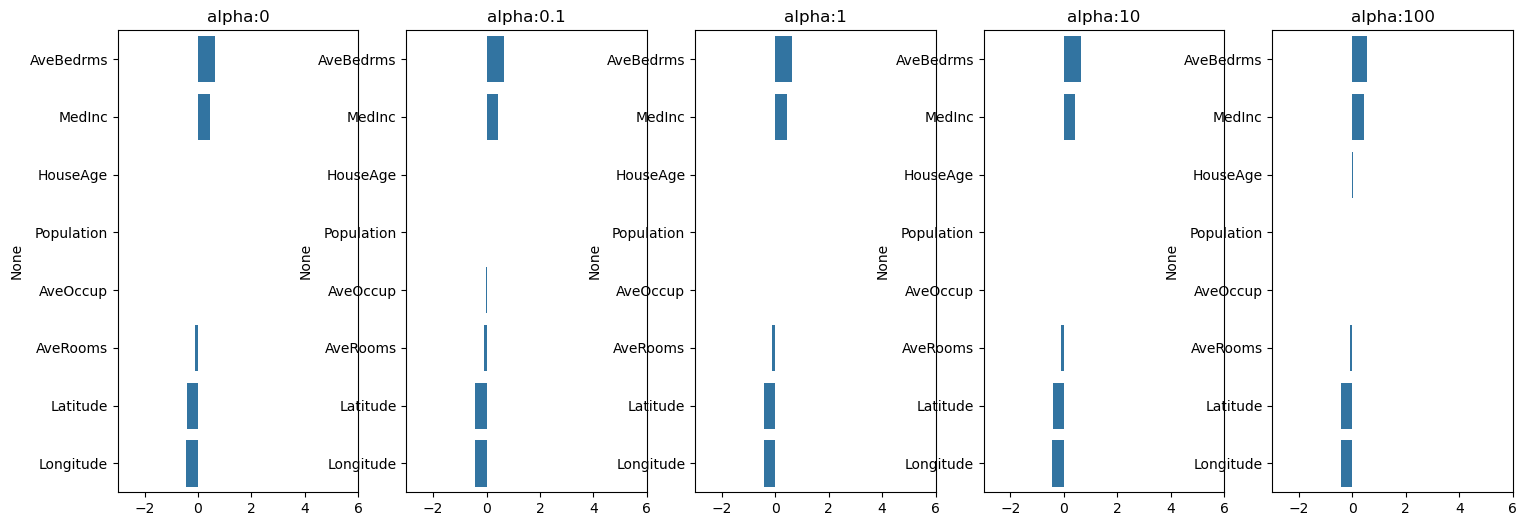

In [4]:
# alpha 값에 따른 회귀계수 시각화
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=5)
# alpha 값에 따른 회귀계수를 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

# alphas 리스트 값을 차례로 입력해 회귀계수 시각화 및 데이터 저장. pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_features, y_target)
    # alpha에 따른 피처별로 회귀계수를 Series로 변환하고 이를 DataFrame의 컬럼으로 추가
    coeff = pd.Series(ridge.coef_, index=X_features.columns)
    colname = 'alpha:'+str(alpha)
    coeff_df[colname] = coeff
    # 막대그래프로 alpha 값에 따른 회귀계수 시각화. 내림차순
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])
    
plt.show()

In [5]:
coeff_df.sort_values(by='alpha:0',ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
AveBedrms,0.645066,0.644965,0.644062,0.635174,0.558249
MedInc,0.436693,0.436683,0.436594,0.435719,0.428210
HouseAge,0.009436,0.009436,0.009437,0.009452,0.009592
Population,-0.000004,-0.000004,-0.000004,-0.000004,-0.000003
AveOccup,-0.003787,-0.003787,-0.003786,-0.003785,-0.003773
AveRooms,-0.107322,-0.107303,-0.107133,-0.105456,-0.091012
Latitude,-0.421314,-0.421313,-0.421299,-0.421156,-0.419061
Longitude,-0.434514,-0.434511,-0.434485,-0.434217,-0.430993


[라쏘 회귀]
: W의 절댓값에 페널티를 부여하는 방식 , 불필요한 회귀계수를 급격히 감소시켜 0으로 만드는 규제 모델
-> 적절한 피처만 회귀에 포함시키는 피처 선택의 특성

In [6]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha 값에 따른 회귀모델의 폴드 평균 rmse를 출력, 회귀계수 값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, X_features_n=None, y_target_n=None,
                       verbose=True, return_coeff=True):
    coeff_df = pd.DataFrame() # 빈 데이터프레임 생성
    if verbose : print('#######', model_name, '#######')
    for param in params:
        if model_name == 'Ridge':
            model = Ridge(alpha=param)
        elif model_name == 'Lasso':
            model = Lasso(alpha=param)
        elif model_name == 'ElasticNet':
            model = ElasticNet(alpha=param, l1_ratio=0.7) # l1_ratio는 0.7로 고정시킴
        
        mse_scores = -cross_val_score(model, X_features_n, y_target_n, scoring='neg_mean_squared_error', cv=5)
        avg_rmse = np.mean(np.sqrt(mse_scores))
        print('alpha {0}일 때 5 폴드 세트의 평균 rmse:{1:.3f}'.format(param, avg_rmse))
        
        # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀계수 추출
        model.fit(X_features_n, y_target_n)
        if return_coeff:
            # alpha에 따른 피처별 회귀계수를 Series로 변환하고 이를 DataFrame의 컬럼으로 추가
            coeff = pd.Series(model.coef_, index=X_features_n.columns)
            colname = 'alpha:'+str(param)
            coeff_df[colname] = coeff
            
    return coeff_df

In [7]:
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_features_n=X_features, y_target_n=y_target)

####### Lasso #######
alpha 0.07일 때 5 폴드 세트의 평균 rmse:0.784
alpha 0.1일 때 5 폴드 세트의 평균 rmse:0.813
alpha 0.5일 때 5 폴드 세트의 평균 rmse:0.873
alpha 1일 때 5 폴드 세트의 평균 rmse:1.000
alpha 3일 때 5 폴드 세트의 평균 rmse:1.171


In [8]:
coeff_lasso_df.sort_values(by='alpha:'+str(lasso_alphas[0]), ascending=False) # by='alpha:0.07'

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
MedInc,0.387057,0.390583,0.288855,0.145469,0.000000
HouseAge,0.013391,0.015082,0.012031,0.005815,0.000000
Population,0.000010,0.000018,0.000012,-0.000006,-0.000023
AveRooms,-0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,-0.000000,-0.000000
AveOccup,-0.003409,-0.003323,-0.000000,-0.000000,-0.000000
Longitude,-0.204689,-0.099225,-0.000000,-0.000000,-0.000000
Latitude,-0.212806,-0.114214,-0.000000,-0.000000,-0.000000


[엘라스틱넷 회귀]
: L2,L1규제를 결합한 회귀
라쏘 회귀가 서로 상관관계가 높은 피처들의 경우에 이들 중에서 중요 피처만 셀렉션하고 다른 피처들은 모두 회귀계수를 0으로 만드는 성향이 강함
이러한 상향으로 인해 알파값에 따라 회귀계수 값이 급격히 변동할 수 있는데 이를 완화하기 위해 L2 규제를 라쏘회귀에 추가한 것 


In [9]:
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, X_features_n=X_features, y_target_n=y_target)

####### ElasticNet #######
alpha 0.07일 때 5 폴드 세트의 평균 rmse:0.773
alpha 0.1일 때 5 폴드 세트의 평균 rmse:0.788
alpha 0.5일 때 5 폴드 세트의 평균 rmse:0.855
alpha 1일 때 5 폴드 세트의 평균 rmse:0.931
alpha 3일 때 5 폴드 세트의 평균 rmse:1.171


In [10]:
coeff_elastic_df.sort_values(by='alpha:'+str(elastic_alphas[0]), ascending=False) # by='alpha:0.07'

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
MedInc,0.384500,0.385980,0.318532,0.213455,0.000000
HouseAge,0.012534,0.013697,0.013662,0.009156,0.000000
Population,0.000007,0.000012,0.000018,0.000003,-0.000023
AveRooms,0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,-0.000000,-0.000000
AveOccup,-0.003502,-0.003437,-0.000837,-0.000000,-0.000000
Longitude,-0.259559,-0.185737,-0.000000,-0.000000,-0.000000
Latitude,-0.264115,-0.195109,-0.000000,-0.000000,-0.000000


[선형 회귀 모델을 위한 데이터 변환]
: 선형 회귀 모델은 피처와 타겟값 간에 선형의 관계가 있다고 가정하고 이러한 최적의 선형 함수를 찾아내 결과값을 예측함
선형회귀모델은 피처값과 타겟값의 분포가 정규분포 형태 선호
피처값과 타겟값의 분포가 왜곡된 분포의 경우 예측 성능에 부정적 영향을 미칠 수 있음
-> 선형 회귀 모델을 적용하기 전에 먼저 데이터에 대한 스케일링/정규화 작업을 수행하는 것이 일반적

- 피처값 변환-로그변환
원래 값에 log함수를 적용하면 정규분포에 가까운 형태로 값이 분포된다
스케일링, 다항특성 변환보다 많이 사용됨

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

<Axes: >

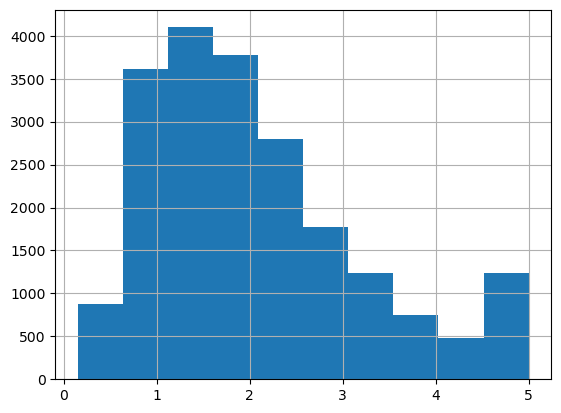

In [12]:
californiaDF['PRICE'].hist()

In [13]:
def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data
        
    
    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)
        
    return scaled_data

In [21]:
alphas = [0.1, 1, 10, 100]

scale_methods = [(None, None), 
                 ('Standard', None), 
                 ('Standard', 2),
                 ('MinMax', None), 
                 ('MinMax', 2)]
for scale_method in scale_methods:
    X_features_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], input_data=X_features)
    print('\n## 변환 유형:{0}, Polylnomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge',params=alphas, X_features_n=X_features_scaled, y_target_n=y_target,
                       verbose=False, return_coeff=False)


## 변환 유형:None, Polylnomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 rmse:0.746
alpha 1일 때 5 폴드 세트의 평균 rmse:0.746
alpha 10일 때 5 폴드 세트의 평균 rmse:0.746
alpha 100일 때 5 폴드 세트의 평균 rmse:0.746

## 변환 유형:Standard, Polylnomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 rmse:0.746
alpha 1일 때 5 폴드 세트의 평균 rmse:0.746
alpha 10일 때 5 폴드 세트의 평균 rmse:0.746
alpha 100일 때 5 폴드 세트의 평균 rmse:0.746

## 변환 유형:Standard, Polylnomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 rmse:3.323
alpha 1일 때 5 폴드 세트의 평균 rmse:2.850
alpha 10일 때 5 폴드 세트의 평균 rmse:1.314
alpha 100일 때 5 폴드 세트의 평균 rmse:0.719

## 변환 유형:MinMax, Polylnomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 rmse:0.745
alpha 1일 때 5 폴드 세트의 평균 rmse:0.748
alpha 10일 때 5 폴드 세트의 평균 rmse:0.754
alpha 100일 때 5 폴드 세트의 평균 rmse:0.816

## 변환 유형:MinMax, Polylnomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 rmse:0.726
alpha 1일 때 5 폴드 세트의 평균 rmse:0.742
alpha 10일 때 5 폴드 세트의 평균 rmse:0.755
alpha 100일 때 5 폴드 세트의 평균 rmse:0.789


[로지스틱 회귀]
: 선형 회귀 방식을 분류에 적용한 알고리즘
선형함수의 회귀 최적선을 찾는 것이 아니라 시그모이드 함수의 최적선을 찾고 이 시그모이드 함수의 반환 값을 확률로 간주해 확률에 따라 분류 결정
주로 이진 분류에 사용됨
예측값은 예측확률을 의미하고 0.5이상은 1, 0.5이하면 0으로 예측

-Odds?
: 사건 발생의 확률을 발생하지 않을 확률로 나눈 값
-> 성공할 확률이 실패할 확률의 몇 배인지를 나타내는 값


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer=load_breast_cancer()


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler=StandardScaler()
data_scaled=scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test=train_test_split(data_scaled,cancer.target,test_size=0.3,random_state=0)

In [17]:
from sklearn.metrics import accuracy_score,roc_auc_score
lr_clf=LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds=lr_clf.predict(X_test)
lr_preds_proba=lr_clf.predict_proba(X_test)[:,1]

print('accuracy:,{0:,.3f},roc_auc:{1:,.3f}'.format(accuracy_score(y_test,lr_preds),roc_auc_score(y_test,lr_preds_proba)))

accuracy:,0.977,roc_auc:0.995


In [22]:
solvers=['lbfgs','liblinear','newton-cg','sag','saga']

for solver in solvers:
    lr_clf=LogisticRegression(solver=solver,max_iter=600)
    lr_clf.fit(X_train,y_train)
    lr_preds=lr_clf.predict(X_test)
    lr_preds_proba=lr_clf.predict_proba(X_test)[:,1]

print('solver:{0},accuracy:{1:.3f},roc_auc:{2:.3f}'.format(solver,
                                                          accuracy_score(y_test,lr_preds),
                                                          roc_auc_score(y_test,lr_preds_proba)))

solver:saga,accuracy:0.982,roc_auc:0.995


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = [{'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 5, 10]},
        {'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 5, 10]}]

lr_clf = LogisticRegression(max_iter=1000)

grid_clf = GridSearchCV(
    lr_clf,
    param_grid=params,
    scoring='accuracy',
    cv=3)

grid_clf.fit(data_scaled, cancer.target)

print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(
    grid_clf.best_params_,
    grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979
